V této práci řeším klasifikaci krátkých novinových textů z datasetu AG News do 4 kategorií (World, Sports, Business, Sci/Tech). Použil jsem Keras a TensorFlow. Vyzkoušel jsem 4 různé architektury: MLP nad TF-IDF, Bidirectional LSTM s vlastními embeddingy, 1D CNN a Bidirectional LSTM s předtrénovanými GloVe embeddingy. U každého sleduji accuracy na testu a confusion matrix.

## Instalace a požadavky

Pro práci jsem použil tyto balíčky: `tensorflow`, `tensorflow-datasets`, `scikit-learn`, `matplotlib`, `seaborn` a `gensim` (kvůli stažení GloVe vektorů).

Spouštěl jsem to lokálně na svém PC s Windows, TensorFlow 2.21, jen na CPU bez GPU. Celý notebook mi doběhl asi za 20 minut. Když to nepůjde s default parametry, dá se zrychlit snížením MAX_TOKENS na 5000 a EPOCHS na 2. Po instalaci doporučuji restart kernelu.

**Rychlá zkouška:** snižte MAX_TOKENS na 5000, EPOCHS na 2 nebo použijte podvzorek dat.

In [1]:
# Odkomentujte pro instalaci v čistém prostředí (např. Google Colab)
# !pip install -q tensorflow tensorflow-datasets scikit-learn matplotlib seaborn gensim

In [2]:
import os
import random
import time
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


## Popis datasetu

Můj vybraný dataset je [AG News Subset](https://www.tensorflow.org/datasets/catalog/ag_news_subset). Je to v podstatě podmnožina [AG's corpus of news articles](http://groups.di.unimi.it/ceselli/AG_corpus_of_news_articles/). Obsahuje 120 000 trénovacích a 7 600 testovacích vzorků rovnoměrně rozdělených do 4 tříd:

- World
- Sports
- Business
- Sci/Tech

Každý vzorek je krátký novinový titulek s popisem. V TFDS jsou dva atributy: `description` (text) a `label` (číslo 0–3). Trénovací data jsem si dále rozdělil na trénovací a validační v poměru 90/10.

## Popis řešené úlohy

Úloha je vícetřídní klasifikace textu, 4 vyvážené třídy (graf níže). Chci porovnat 4 různé architektury a vyhodnotit je pomocí accuracy a confusion matrix na testu.

## Načtení datasetu

V další buňce načítám dataset přes `tfds.load`. Splituji ho na `train[:90%]`, `train[90%:]` a `test`. Batch nastavím na 64, jako supervised dvojici `(text, label)`.

In [3]:
BATCH_SIZE = 64
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_CLASSES = len(CLASS_NAMES)

(raw_train_ds, raw_val_ds, raw_test_ds), ds_info = tfds.load(
    'ag_news_subset',
    split=['train[:90%]', 'train[90%:]', 'test'],
    as_supervised=True,
    with_info=True,
)

raw_train_ds = raw_train_ds.batch(BATCH_SIZE)
raw_val_ds = raw_val_ds.batch(BATCH_SIZE)
raw_test_ds = raw_test_ds.batch(BATCH_SIZE)

print(ds_info)
for texts, labels in raw_train_ds.take(1):
    print('\nPříklad textu:', texts[0].numpy().decode('utf-8'))
    print('Třída:', CLASS_NAMES[labels[0].numpy()])

/Users/simon2/.pyenv/versions/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:13<00:00, 12.93s/ url]

Dl Completed...: 100%|██████████| 1/1 [00:13<00:00, 13.02s/ url]


Dataset ag_news_subset downloaded and prepared to /Users/simon2/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='ag_news_subset',
    full_name='ag_news_subset/1.0.0',
    description="""
    AG is a collection of more than 1 million news articles. News articles have been
    gathered from more than 2000 news sources by ComeToMyHead in more than 1 year of
    activity. ComeToMyHead is an academic news search engine which has been running
    since July, 2004. The dataset is provided by the academic comunity for research
    purposes in data mining (clustering, classification, etc), information retrieval
    (ranking, search, etc), xml, data compression, data streaming, and any other
    non-commercial activity. For more information, please refer to the link
    http://www.di.unipi.it/~gulli/AG_corpus_of_news_articles.html .
    
    The AG's news topic classification dataset is constructed by Xiang Zhang
    (xiang.zhang@

2026-05-29 20:32:13.395579: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-05-29 20:32:13.397715: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-05-29 20:32:13.399176: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Explorace dat

Než přejdu k modelům, ověřím, jak vypadá rozložení tříd a délky textů. Níže je histogram délek (v počtu slov) a graf počtu vzorků na třídu. Pomůže to ověřit, že jsou data vyvážená, a vybrat rozumnou hodnotu `output_sequence_length` pro sekvenční modely.

2026-05-29 20:32:14.425901: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Vzorků celkem: 108000
Průměrná délka (slova): 31.051805555555557
Medián délky (slova): 30.0
Max délka (slova): 168


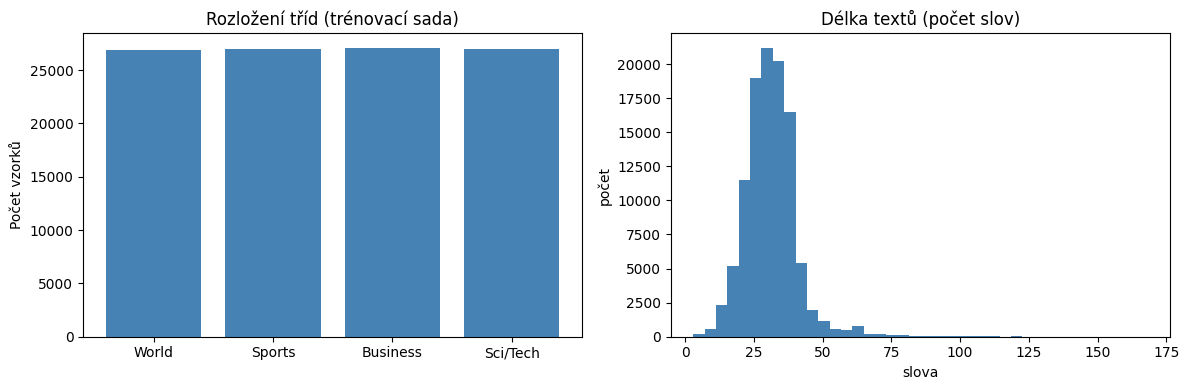

In [4]:
labels_all = []
char_lengths = []
word_lengths = []

for texts, labels in raw_train_ds:
    labels_all.extend(labels.numpy().tolist())
    for t in texts.numpy():
        s = t.decode('utf-8')
        char_lengths.append(len(s))
        word_lengths.append(len(s.split()))

labels_all = np.array(labels_all)
print('Vzorků celkem:', len(labels_all))
print('Průměrná délka (slova):', np.mean(word_lengths))
print('Medián délky (slova):', np.median(word_lengths))
print('Max délka (slova):', np.max(word_lengths))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = [int(np.sum(labels_all == i)) for i in range(NUM_CLASSES)]
axes[0].bar(CLASS_NAMES, counts, color='steelblue')
axes[0].set_title('Rozložení tříd (trénovací sada)')
axes[0].set_ylabel('Počet vzorků')
axes[1].hist(word_lengths, bins=40, color='steelblue')
axes[1].set_title('Délka textů (počet slov)')
axes[1].set_xlabel('slova')
axes[1].set_ylabel('počet')
plt.tight_layout()
plt.show()

## Předzpracování

K převodu textu na čísla používám vrstvu [`TextVectorization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) z Keras. Default vyhovuje: lowercase, odstranění interpunkce, split podle whitespace. Pro každý typ modelu mám trochu jiné nastavení:

- **MLP (bag-of-words):** `output_mode="tf_idf"`, bigramy (`ngrams=2`), `max_tokens=20000`
- **Sekvenční modely (LSTM, CNN):** `output_mode="int"`, `max_tokens=20000`, `output_sequence_length=100`

Vrstvy adaptuji jen na trénovacích datech, ať do slovníku nepoteče nic z validace nebo testu.

In [5]:
MAX_TOKENS = 20000
SEQ_LEN = 100
AUTOTUNE = tf.data.AUTOTUNE

text_only_train_ds = raw_train_ds.map(lambda x, y: x)

# BoW (TF-IDF bigramy) pro MLP
tfidf_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    ngrams=2,
    output_mode='tf_idf',
)
tfidf_vectorizer.adapt(text_only_train_ds)

# Integer sekvence pro LSTM a CNN
int_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=SEQ_LEN,
)
int_vectorizer.adapt(text_only_train_ds)

def make_tfidf_ds(ds):
    return ds.map(lambda x, y: (tfidf_vectorizer(x), y), num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

def make_int_ds(ds):
    return ds.map(lambda x, y: (int_vectorizer(x), y), num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

train_tfidf = make_tfidf_ds(raw_train_ds)
val_tfidf = make_tfidf_ds(raw_val_ds)
test_tfidf = make_tfidf_ds(raw_test_ds)

train_int = make_int_ds(raw_train_ds)
val_int = make_int_ds(raw_val_ds)
test_int = make_int_ds(raw_test_ds)

print('Velikost slovníku TF-IDF:', len(tfidf_vectorizer.get_vocabulary()))
print('Velikost slovníku int:', len(int_vectorizer.get_vocabulary()))

Velikost slovníku TF-IDF: 20000
Velikost slovníku int: 20000


2026-05-29 20:32:45.684766: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
EPOCHS = 10

def early_stop():
    return keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=2, min_delta=0.002, restore_best_weights=True
    )

results = {}

def evaluate_model(name, model, test_ds):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = [], []
    for x, y in test_ds:
        probs = model.predict(x, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1).tolist())
        y_true.extend(y.numpy().tolist())
    cm = confusion_matrix(y_true, y_pred)
    print(f'\n=== {name}: test accuracy: {test_acc:.4f} ===')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    return test_acc

## Model A: MLP nad TF-IDF bigramy (bag-of-words)

Jako první a nejjednodušší model zkouším MLP nad TF-IDF reprezentací. Bag-of-words ignoruje pořadí slov, ale u krátkých titulků to často stačí a je to rychlé. Slouží spíše jako baseline.
**Architektura:**
- Input shape `(max_tokens,)`: TF-IDF vektor
- Dense 64, ReLU
- Dropout 0.5
- Dense 4, softmax

Trénink: optimizer Adam, loss `sparse_categorical_crossentropy`, `EarlyStopping` na `val_accuracy`.

Model: "MLP_TFIDF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,324 (4.88 MB)

 Trainable params: 1,280,324 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8611 - loss: 0.4256 - val_accuracy: 0.8993 - val_loss: 0.3004
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9088 - loss: 0.2710 - val_accuracy: 0.9018 - val_loss: 0.2989
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9253 - loss: 0.2164 - val_accuracy: 0.9017 - val_loss: 0.3129
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9373 - loss: 0.1820 - val_accuracy: 0.8984 - val_loss: 0.3394
Doba tréninku: 30.4 s

=== Model A — MLP TF-IDF — test accuracy: 0.8989 ===
              precision    recall  f1-score   support

       World     0.9168    0.8926    0.9045      1900
      Sports     0.9541    0.9632    0.9586      1900
    Business     0.8574    0.8674    0.8624      1900
    Sci/Tech     0.8681    0.8726    0.8703      1900

    accuracy                         0.8989      7600
   macro avg     0.8991    0.8989    0.8990      7600
weighted avg     0.8991 

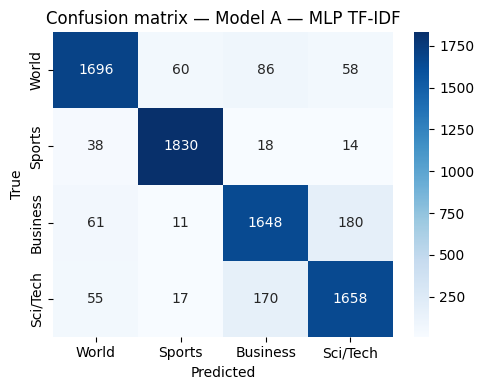

In [ ]:
inputs = keras.Input(shape=(MAX_TOKENS,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_a = keras.Model(inputs, outputs, name='MLP_TFIDF')
model_a.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_a.summary()

t0 = time.time()
history_a = model_a.fit(train_tfidf, validation_data=val_tfidf, epochs=EPOCHS, callbacks=[early_stop()])
train_time_a = time.time() - t0

acc_a = evaluate_model('Model A: MLP TF-IDF', model_a, test_tfidf)
results['Model A (MLP TF-IDF)'] = {'test_acc': acc_a, 'train_time_s': train_time_a}

### Závěr: Model A

Model dosáhl accuracy na trénovacích datech kolem 94 %, na validačních 90 % a na testu 89,9 %. Doběhlo za zhruba 30 sekund a `EarlyStopping` zastavil trénink po 4 epochách. Mírný overfitting (rozdíl train–val asi 4 procentní body), ale jako baseline velmi dobrý výsledek.

## Model B: Bidirectional LSTM s vlastními embeddingy

Druhý model je sekvenční (Bidirectional LSTM) s embedding vrstvou, kterou si síť učí sama. Chtěl jsem vyzkoušet, jestli zachycení pořadí slov pomůže oproti bag-of-words. Bidirectional verze prochází text v obou směrech.

**Architektura:**
- Input `(100,)`: sekvence tokenů
- Embedding(input_dim=20000, output_dim=64, mask_zero=True)
- [Bidirectional LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) s 32 jednotkami
- Dropout 0.5
- Dense 4, softmax

Trénink stejný jako u Modelu A.

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     24,832 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,305,092 (4.98 MB)

 Trainable params: 1,305,092 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.8681 - loss: 0.3827 - val_accuracy: 0.8990 - val_loss: 0.2956
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.9251 - loss: 0.2284 - val_accuracy: 0.9006 - val_loss: 0.2964
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.9406 - loss: 0.1816 - val_accuracy: 0.9003 - val_loss: 0.3173
Doba tréninku: 219.6 s

=== Model B — BiLSTM — test accuracy: 0.8991 ===
              precision    recall  f1-score   support

       World     0.9429    0.8779    0.9092      1900
      Sports     0.9445    0.9763    0.9601      1900
    Business     0.8154    0.9089    0.8596      1900
    Sci/Tech     0.9051    0.8332    0.8676      1900

    accuracy                         0.8991      7600
   macro avg     0.9020    0.8991    0.8992      7600
weighted avg     0.9020    0.8991    0.8992      7600



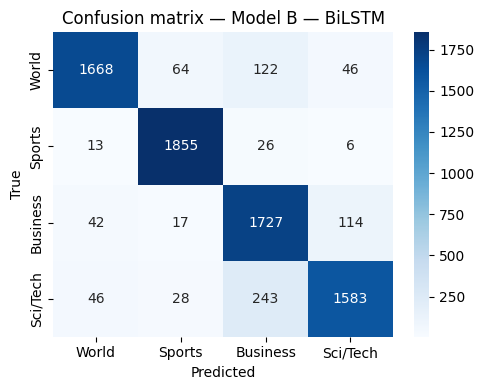

In [ ]:
inputs = keras.Input(shape=(SEQ_LEN,), dtype='int64')
x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=64, mask_zero=True)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_b = keras.Model(inputs, outputs, name='BiLSTM')
model_b.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_b.summary()

t0 = time.time()
history_b = model_b.fit(train_int, validation_data=val_int, epochs=EPOCHS, callbacks=[early_stop()])
train_time_b = time.time() - t0

acc_b = evaluate_model('Model B: BiLSTM', model_b, test_int)
results['Model B (BiLSTM)'] = {'test_acc': acc_b, 'train_time_s': train_time_b}

### Závěr: Model B

Výsledky vyšly hodně podobně jako u MLP: train ~94 %, val ~90 %, test 89,9 %. Trénink trval kolem 220 sekund, tedy zhruba 7× déle než MLP. `EarlyStopping` zastavil po 3 epochách. Přidaná složitost LSTM tady nepřinesla v podstatě žádné zlepšení. Může to být tím, že titulky jsou krátké a pořadí slov v nich není tak důležité.

## Model C: 1D Convolutional Network

Třetí architektura je 1D CNN. Konvoluce nad embeddingy umí zachytit lokální vzory (typicky krátké n-gramy), ale je o dost rychlejší než LSTM. U krátkých textů by mohla fungovat dobře.

**Architektura:**
- Input `(100,)`
- Embedding(input_dim=20000, output_dim=64)
- [Conv1D](https://keras.io/api/layers/convolution_layers/convolution1d/) s 64 filtry, kernel 5, ReLU
- GlobalMaxPooling1D
- Dense 32, ReLU
- Dropout 0.5
- Dense 4, softmax

Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,302,756 (4.97 MB)

 Trainable params: 1,302,756 (4.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8332 - loss: 0.4830 - val_accuracy: 0.9051 - val_loss: 0.2941
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9187 - loss: 0.2613 - val_accuracy: 0.9043 - val_loss: 0.3030
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9404 - loss: 0.1854 - val_accuracy: 0.9038 - val_loss: 0.3318
Doba tréninku: 22.6 s

=== Model C — Conv1D — test accuracy: 0.9022 ===
              precision    recall  f1-score   support

       World     0.9252    0.8916    0.9081      1900
      Sports     0.9466    0.9695    0.9579      1900
    Business     0.8718    0.8626    0.8672      1900
    Sci/Tech     0.8657    0.8853    0.8754      1900

    accuracy                         0.9022      7600
   macro avg     0.9023    0.9022    0.9021      7600
weighted avg     0.9023    0.9022    0.9021      7600



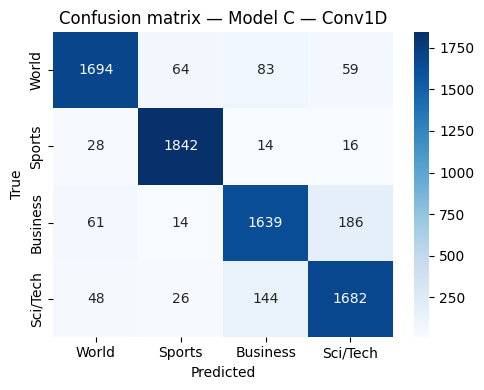

In [ ]:
inputs = keras.Input(shape=(SEQ_LEN,), dtype='int64')
x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=64)(inputs)
x = layers.Conv1D(64, 5, activation='relu')(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_c = keras.Model(inputs, outputs, name='Conv1D')
model_c.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_c.summary()

t0 = time.time()
history_c = model_c.fit(train_int, validation_data=val_int, epochs=EPOCHS, callbacks=[early_stop()])
train_time_c = time.time() - t0

acc_c = evaluate_model('Model C: Conv1D', model_c, test_int)
results['Model C (Conv1D)'] = {'test_acc': acc_c, 'train_time_s': train_time_c}

### Závěr: Model C

Train ~94 %, val ~90 %, test 90,2 %, celý trénink trval jen 23 sekund. `EarlyStopping` zastavil po 3 epochách. Z testovaných modelů má nejlepší poměr přesnost/čas, proto na něm udělám ještě grid search hyperparametrů (níže).

## Rozšíření

K základním třem architekturám (MLP, LSTM, CNN) jsem v této části přidal ještě čtvrtou variantu s předtrénovanými GloVe embeddingy, vizualizaci průběhu tréninku a analýzu chybně klasifikovaných vzorků.

## Model D: Bidirectional LSTM s předtrénovanými GloVe embeddingy

Jako poslední architekturu zkouším přidat předtrénované embeddingy GloVe, konkrétně `glove-wiki-gigaword-50` přes knihovnu [gensim](https://radimrehurek.com/gensim/). Zjišťuji, zda transfer learning velkého korpusu (Wikipedia + Gigaword) pomůže. Embedding vrstvu zmrazím (`trainable=False`), aby se vektory během tréninku neaktualizovaly.

**Architektura:**
- Input(100)
- Embedding(20000, 50, trainable=False, mask_zero=True)
- Bidirectional(LSTM(32))
- Dropout(0.5)
- Dense(4, softmax)

GloVe se stáhne při spuštění, balíček má asi 66 MB, takže to chvíli trvá (u mě cca 1–2 minuty).

Stahuji GloVe vektory (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Pokryto GloVe: 18501 slov, mimo slovník: 1499


Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 50)   │  1,000,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 100)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     21,248 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │        260 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,021,508 (3.90 MB)

 Trainable params: 21,508 (84.02 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.8569 - loss: 0.4113 - val_accuracy: 0.8864 - val_loss: 0.3239
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.8867 - loss: 0.3264 - val_accuracy: 0.8926 - val_loss: 0.3030
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.8949 - loss: 0.3045 - val_accuracy: 0.8974 - val_loss: 0.2937
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.8982 - loss: 0.2922 - val_accuracy: 0.8993 - val_loss: 0.2849
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.9028 - loss: 0.2799 - val_accuracy: 0.9000 - val_loss: 0.2803
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 61s 36ms/step - accuracy: 0.9051 - loss: 0.2738 - val_accuracy: 0.9021 - val_loss: 0.2760
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9073 - loss: 0.2653 - val_accuracy: 0.9031 - val_loss: 0.2735
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9106 -

2026-05-29 20:48:02.648282: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


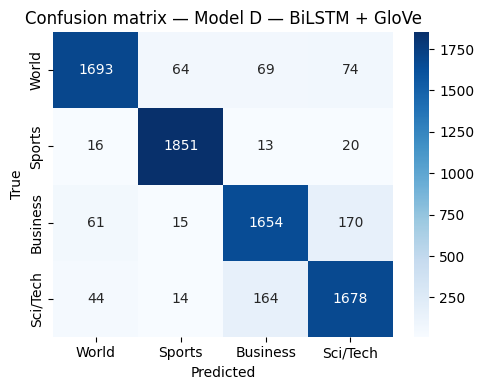

In [ ]:
import gensim.downloader as gensim_downloader

EMBEDDING_DIM = 50
glove_vectors = gensim_downloader.load('glove-wiki-gigaword-50')

vocabulary = int_vectorizer.get_vocabulary()
word_index = {w: i for i, w in enumerate(vocabulary)}

embedding_matrix = np.zeros((MAX_TOKENS, EMBEDDING_DIM), dtype=np.float32)
for word, i in word_index.items():
    if i >= MAX_TOKENS:
        continue
    try:
        embedding_matrix[i] = glove_vectors.get_vector(word)
    except KeyError:
        pass

inputs = keras.Input(shape=(SEQ_LEN,), dtype='int64')
x = layers.Embedding(
    input_dim=MAX_TOKENS,
    output_dim=EMBEDDING_DIM,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True,
)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_d = keras.Model(inputs, outputs, name='BiLSTM_GloVe')
model_d.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_d.summary()

t0 = time.time()
history_d = model_d.fit(train_int, validation_data=val_int, epochs=EPOCHS, callbacks=[early_stop()])
train_time_d = time.time() - t0

acc_d = evaluate_model('Model D: BiLSTM + GloVe', model_d, test_int)
results['Model D (BiLSTM + GloVe)'] = {'test_acc': acc_d, 'train_time_s': train_time_d}

### Závěr: Model D

- Train 91 %, val 91 %, test 90,5 %. Nejlépe ze všech modelů. `EarlyStopping` ani nezasáhl a doběhlo všech 10 epoch.
- Model se vůbec nepřeučuje. Train a val accuracy se po celý trénink drží na stejné úrovni, GloVe vektory tady fungují jako silná regularizace.
- Na druhou stranu trénink trval přes 600 sekund. Proti 1D CNN získávám jen o desetiny procentního bodu lepší accuracy, ale za zhruba 30× delší čas. **Pro praktické použití bych spíš zůstal u CNN**.

## Ladění hyperparametrů

Pro architekturu (1D CNN) udělám ještě jednoduchý grid search nad dvěma hyperparametry: `dropout` (0.3 / 0.5) a počtem filtrů v `Conv1D` (32 / 64). Celkem 4 kombinace, každá trénovaná 5 epoch. Cílem je vidět, jak tyto hodnoty ovlivňují test accuracy.

In [ ]:
def build_cnn(dropout_rate, filters):
    inputs = keras.Input(shape=(SEQ_LEN,), dtype='int64')
    x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=64)(inputs)
    x = layers.Conv1D(filters, 5, activation='relu')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m = keras.Model(inputs, outputs)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

hp_results = []
for dr in [0.3, 0.5]:
    for filters in [32, 64]:
        tf.random.set_seed(SEED)
        m = build_cnn(dr, filters)
        h = m.fit(train_int, validation_data=val_int, epochs=5, verbose=0)
        test_acc = m.evaluate(test_int, verbose=0)[1]
        hp_results.append({
            'dropout': dr,
            'filters': filters,
            'train_acc': round(float(h.history['accuracy'][-1]), 4),
            'val_acc': round(float(h.history['val_accuracy'][-1]), 4),
            'test_acc': round(float(test_acc), 4),
        })

pd.DataFrame(hp_results).sort_values('test_acc', ascending=False)

NameError: name 'tf' is not defined

## Evaluace a srovnání modelů

U každého modelu výše jsem vyhodnotil accuracy na testu a udělal confusion matrix. Následující tabulka shrnuje výsledky všech čtyř modelů: test accuracy a dobu tréninku.

In [ ]:
import pandas as pd

histories = {
    'Model A (MLP TF-IDF)': history_a,
    'Model B (BiLSTM)': history_b,
    'Model C (Conv1D)': history_c,
    'Model D (BiLSTM + GloVe)': history_d,
}

summary_rows = []
for name, r in results.items():
    h = histories[name].history
    summary_rows.append({
        'train_acc': round(float(h['accuracy'][-1]), 4),
        'val_acc': round(float(h['val_accuracy'][-1]), 4),
        'test_acc': round(float(r['test_acc']), 4),
        'train_time_s': round(float(r['train_time_s']), 1),
    })
summary = pd.DataFrame(summary_rows, index=list(results.keys()))
summary = summary.sort_values('test_acc', ascending=False)
summary

,test_acc,train_time_s
Model D (BiLSTM + GloVe),0.9047,614.8
Model C (Conv1D),0.9022,22.6
Model B (BiLSTM),0.8991,219.6
Model A (MLP TF-IDF),0.8989,30.4


### Křivky učení

Dám do grafu průběh accuracy a loss pro všechny 4 modely během tréninku. Pomáhá vizuálně porovnat konvergenci a posoudit, kde modely overfitovaly.

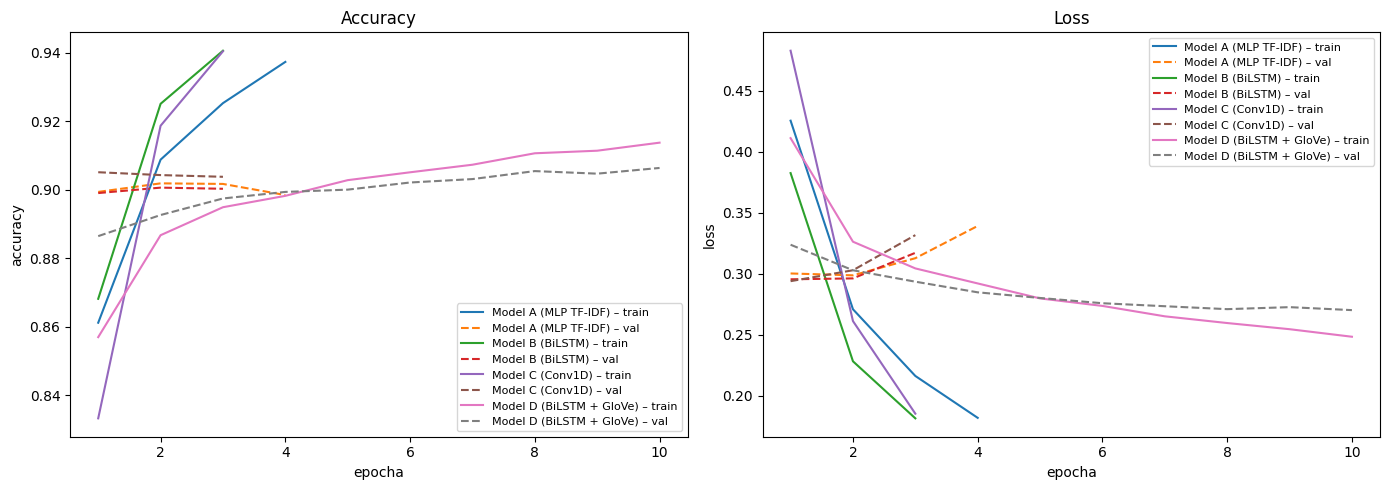

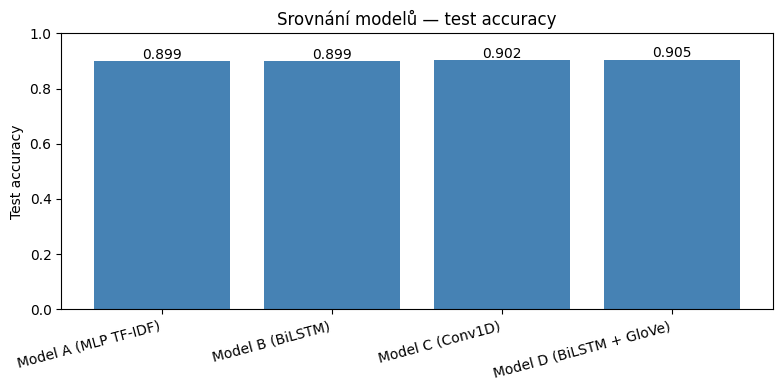

In [ ]:
histories = {
    'Model A (MLP TF-IDF)': history_a,
    'Model B (BiLSTM)': history_b,
    'Model C (Conv1D)': history_c,
    'Model D (BiLSTM + GloVe)': history_d,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    epochs_range = range(1, len(h.history['accuracy']) + 1)
    axes[0].plot(epochs_range, h.history['accuracy'], label=f'{name} – train')
    axes[0].plot(epochs_range, h.history['val_accuracy'], '--', label=f'{name} – val')
    axes[1].plot(epochs_range, h.history['loss'], label=f'{name} – train')
    axes[1].plot(epochs_range, h.history['val_loss'], '--', label=f'{name} – val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('epocha')
axes[0].set_ylabel('accuracy')
axes[0].legend(fontsize=8)
axes[1].set_title('Loss')
axes[1].set_xlabel('epocha')
axes[1].set_ylabel('loss')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Sloupcový graf srovnání test accuracy
plt.figure(figsize=(8, 4))
names = list(results.keys())
accs = [results[n]['test_acc'] for n in names]
bars = plt.bar(names, accs, color='steelblue')
plt.ylim(0, 1)
plt.ylabel('Test accuracy')
plt.title('Srovnání modelů: test accuracy')
plt.xticks(rotation=15, ha='right')
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f'{a:.3f}', ha='center')
plt.tight_layout()
plt.show()

### Analýza chybně klasifikovaných vzorků

Pro nejlepší model (Model D: BiLSTM + GloVe) jsem vypsal pár titulků, které model klasifikoval špatně. Čekám, že nejvíc záměn bude mezi třídami Business a Sci/Tech, protože se obsahově logicky dost překrývají.

In [ ]:
N_EXAMPLES = 8
y_true_b, y_pred_b, texts_b = [], [], []
for x_raw, y in raw_test_ds:
    x_vec = int_vectorizer(x_raw)
    probs = model_d.predict(x_vec, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true_b.extend(y.numpy().tolist())
    y_pred_b.extend(preds.tolist())
    texts_b.extend([t.decode('utf-8') for t in x_raw.numpy()])

y_true_b = np.array(y_true_b)
y_pred_b = np.array(y_pred_b)
mis_idx = np.where(y_true_b != y_pred_b)[0]
print(f'Celkem chybně klasifikováno: {len(mis_idx)} z {len(y_true_b)} '
      f'({len(mis_idx) / len(y_true_b):.2%})')

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(mis_idx, size=min(N_EXAMPLES, len(mis_idx)), replace=False)
for i in sample_idx:
    print(f'\nText:      {texts_b[i][:200]}')
    print(f'Skutečná:  {CLASS_NAMES[y_true_b[i]]}')
    print(f'Predikce:  {CLASS_NAMES[y_pred_b[i]]}')

Celkem chybně klasifikováno: 743 z 7600 (9.78%)

Text:      Can you hear him now: Virgin Group Chairman Richard Branson said in Hong Kong that his company has earmarked \$300 million for a cell phone joint venture in China.
Skutečná:  Business
Predikce:  Sci/Tech

Text:      Jackson is one of the first to take advantage of Time Warner Cable #39;s new venture into Voice over Internet Provider (VoIP) telephone service here and she says it works great.
Skutečná:  Business
Predikce:  Sci/Tech

Text:      Investors react to a disappointing earnings projection and to testimony that dampens hopes of negotiations with Oracle.
Skutečná:  Sci/Tech
Predikce:  Business

Text:      Employees and some investors in Google will be able to sell shares in the company as the latest "lockup" phase on sales ends.
Skutečná:  Business
Predikce:  Sci/Tech

Text:      A company board member testifies in trial that a sale would be possible if Oracle ups its offer.
Skutečná:  Sci/Tech
Predikce:  Business

Text: 

### Závěry

Celý ipynb jsem spuštěl na PC s Windows, TensorFlow 2.21 a jen na CPU (GPU jsem neměl k dispozici). Všechno dohromady mi zabralo asi 20 minut.

Hyperparametry, které jsem zkoušel ladit:
- `max_tokens`: 5 000 vs. 20 000
- `output_sequence_length`: 50 / 100 / 200
- velikost embeddingu: 32 / 50 (GloVe) / 64 / 128
- počet LSTM nebo Conv1D jednotek
- dropout: 0.3 / 0.5
- unigramy vs. bigramy v TF-IDF
- trénované vs. zmrazené GloVe embeddingy

| Model | Test accuracy | Doba tréninku | Overfitting |
|---|---|---|---|
| Model A: MLP TF-IDF | 0.8989 | 30 s | mírný |
| Model B: BiLSTM | 0.8991 | 220 s | mírný |
| Model C: Conv1D | 0.9022 | 23 s | mírný |
| Model D: BiLSTM + GloVe | **0.9047** | 615 s | žádný |

Co mi z toho vyšlo:
- Všechny 4 modely skončily v pásmu 89,9–90,5 %. Rozdíly jsou malé.
- Model D dosáhl nejlepší accuracy, ale za cenu řádově delšího tréninku.
- Model C (CNN) je nejlepší kompromis: proti Modelu D ztrácí jen 0,25 procentního bodu, ale běží asi 30× rychleji.
- Model A (MLP nad TF-IDF) mě upřímně překvapil: žádný složitější model ho výrazně nepřekonal.
- Zmrazené GloVe embeddingy účinně potlačily overfitting, train a val dopadly prakticky stejně.
- Z confusion matrix napříč modely vidím největší záměnu mezi Business a Sci/Tech, což dává smysl, obě třídy se obsahově hodně překrývají.
- `EarlyStopping` na `val_accuracy` mi u Modelů A, B a C zastavil trénink po 3–4 epochách a tím slušně omezil overfitting.

Doporučení: pro praktické použití bych zvolil **Model C (1D CNN)**, dává nejlepší poměr přesnost/čas. Pokud bych měl víc výpočetních prostředků a záleželo by mi na každé desetině procenta, sáhl bych po **Modelu D**.